# PRE DATA ANALYSIS

## **4.1 Cohort Profiling**

In [ ]:
import os
import re
import pandas as pd

def parse_time_to_seconds(time_str):
    """Converts HH:MM:SS format into total seconds."""
    parts = time_str.split(':')
    h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
    return h * 3600 + m * 60 + s

def process_summary_file(file_path):
    with open(file_path, 'r') as f:
        content = f.read()

    # Extract patient ID from filename (e.g., chb01-summary.txt -> CHB01)
    patient_id = os.path.basename(file_path).split('-')[0].upper()

    total_file_seconds = 0
    total_seizures = 0
    seizure_duration_seconds = 0
    files_with_seizures = 0

    # Split the document by EDF file entries
    file_blocks = content.split('File Name:')[1:]
    total_files = len(file_blocks) # NEW: Total files extracted here

    # NEW: Calculate Average Channels
    total_channel_lines = len(re.findall(r'Channel \d+:', content))
    channel_list_resets = content.count('Channel 1:') # Counts how many times the channel list is declared
    avg_channels = round(total_channel_lines / channel_list_resets) if channel_list_resets > 0 else 0

    for block in file_blocks:
        # Parse File Duration
        start_match = re.search(r'File Start Time:\s*([\d:]+)', block)
        end_match = re.search(r'File End Time:\s*([\d:]+)', block)

        if start_match and end_match:
            start_sec = parse_time_to_seconds(start_match.group(1))
            end_sec = parse_time_to_seconds(end_match.group(1))

            # Handle midnight crossovers
            if end_sec < start_sec:
                end_sec += 24 * 3600

            total_file_seconds += (end_sec - start_sec)

        # Parse Seizures & Files with Seizures
        seizure_count_match = re.search(r'Number of Seizures in File:\s*(\d+)', block)

        if seizure_count_match:
            num_seizures = int(seizure_count_match.group(1))
            if num_seizures > 0:
                files_with_seizures += 1
                total_seizures += num_seizures

                # Regex handles the line breaks and spaces found in the raw text files
                times = re.findall(r'Start Time:\s*(\d+).*?End Time:\s*(\d+)', block, re.DOTALL | re.IGNORECASE)

                for start, end in times:
                    seizure_duration_seconds += (int(end) - int(start))

    # Calculate Patient-level metrics
    total_hours = total_file_seconds / 3600.0
    seizure_duration_minutes = seizure_duration_seconds / 60.0

    return {
        'Patient ID': patient_id,
        'Total Files': total_files,               # NEW
        'Avg Channels': avg_channels,             # NEW
        'Total Hours': round(total_hours, 2),
        'Total Seizures': total_seizures,
        'Seizure Duration (Mins)': round(seizure_duration_minutes, 2),
        'Files w/ Seizures': files_with_seizures,
        '_raw_seizure_seconds': seizure_duration_seconds
    }

def compile_chbmit_dataset(root_directory):
    """Traverses nested directories to find summary files and builds the final DataFrame."""
    data = []

    for root, dirs, files in os.walk(root_directory):
        for filename in files:
            if filename.endswith("-summary.txt"):
                file_path = os.path.join(root, filename)
                patient_data = process_summary_file(file_path)
                data.append(patient_data)

    # Sort the data alphabetically by Patient ID so the table is ordered
    data = sorted(data, key=lambda x: x['Patient ID'])

    df = pd.DataFrame(data)

    # --- Calculate Global Metrics ---
    total_dataset_seizures = df['Total Seizures'].sum()
    total_dataset_seizure_seconds = df['_raw_seizure_seconds'].sum()

    global_avg_seizure_sec = total_dataset_seizure_seconds / total_dataset_seizures if total_dataset_seizures > 0 else 0
    global_total_seizure_mins = df['Seizure Duration (Mins)'].sum()

    df = df.drop(columns=['_raw_seizure_seconds'])

    # Add a "TOTAL / AGGREGATE" row at the bottom
    totals = pd.Series({
        'Patient ID': 'TOTAL / AVG',
        'Total Files': df['Total Files'].sum(),
        'Avg Channels': round(df['Avg Channels'].mean(), 1), # Averages the patient averages
        'Total Hours': df['Total Hours'].sum(),
        'Total Seizures': total_dataset_seizures,
        'Seizure Duration (Mins)': round(global_total_seizure_mins, 2),
        'Files w/ Seizures': df['Files w/ Seizures'].sum()
    })

    df = pd.concat([df, totals.to_frame().T], ignore_index=True)

    print("\n--- GLOBAL METRICS ---")
    print(f"Total Seizure Duration in Dataset: {round(global_total_seizure_mins, 2)} minutes")
    print(f"Average Seizure Duration (Across all patients): {round(global_avg_seizure_sec, 2)} seconds\n")

    return df

# --- Execution ---
parent_dir = '/content/drive/MyDrive/chbmit_org/chbmit'
dataset_summary_df = compile_chbmit_dataset(parent_dir)

print(dataset_summary_df.to_string(index=False))
dataset_summary_df.to_csv('/content/drive/MyDrive/chbmit_data_description/CHBMIT_Original_Data_Summary.csv', index=False)


--- GLOBAL METRICS ---
Total Seizure Duration in Dataset: 196.49 minutes
Average Seizure Duration (Across all patients): 59.55 seconds

 Patient ID Total Files Avg Channels Total Hours Total Seizures Seizure Duration (Mins) Files w/ Seizures
      CHB01          42           23       40.55              7                    7.48                 7
      CHB02          36           23       35.27              3                     2.9                 3
      CHB03          38           23        38.0              7                    6.82                 7
      CHB04          42           24      156.06              4                    6.47                 3
      CHB05          39           23        39.0              5                    9.38                 5
      CHB06          18           23       66.73             10                    2.97                 7
      CHB07          19           23       67.05              3                    5.57                 3
      CHB08    

## **4.2 Data Selection and Channel Standardization**

In [ ]:
import os
import pandas as pd
import numpy as np
import mne

def compile_preprocessed_stats(preprocessed_dir, events_table_dir):
    """Calculates total files, hours, and exact surviving seizure minutes."""
    data = []

    # Iterate through patient folders
    for patient_folder in sorted(os.listdir(preprocessed_dir)):
        patient_path = os.path.join(preprocessed_dir, patient_folder)

        if not os.path.isdir(patient_path):
            continue

        patient_id = patient_folder.upper()
        total_seconds = 0
        total_files = 0
        total_seizure_files = 0
        total_seizures = 0
        total_seizure_seconds = 0

        # Load the corresponding event tables for this patient
        start_csv = os.path.join(events_table_dir, f"{patient_folder}_start.csv")
        stop_csv = os.path.join(events_table_dir, f"{patient_folder}_stop.csv")

        start_dict, stop_dict = {}, {}
        if os.path.exists(start_csv) and os.path.exists(stop_csv):
            # Read CSVs into dictionaries using the filename as the index
            start_dict = pd.read_csv(start_csv).to_dict('index')
            stop_dict = pd.read_csv(stop_csv).to_dict('index')

        # Iterate through .edf files in the patient folder
        for file in os.listdir(patient_path):
            if not file.endswith('.edf'):
                continue

            filepath = os.path.join(patient_path, file)
            try:
                # Read ONLY the header (super fast, prevents RAM crash)
                raw = mne.io.read_raw_edf(filepath, preload=False, verbose=False)

                # Duration = number of samples / sampling frequency
                duration_sec = raw.n_times / raw.info['sfreq']

                total_seconds += duration_sec
                total_files += 1
            except Exception as e:
                print(f"Error reading {file}: {e}")
                continue

            # Calculate exact seizure details for surviving files
            if file.startswith('seizures_'):
                total_seizure_files += 1

                # Strip 'seizures_' to match the keys in the CSV tables
                orig_record = file.replace('seizures_', '')

                if orig_record in start_dict and orig_record in stop_dict:
                    # Extract values ignoring NaNs
                    starts = [float(x) for x in start_dict[orig_record].values() if pd.notna(x)]
                    stops = [float(x) for x in stop_dict[orig_record].values() if pd.notna(x)]

                    total_seizures += len(starts)
                    for start_time, stop_time in zip(starts, stops):
                        total_seizure_seconds += (stop_time - start_time)

        total_hours = total_seconds / 3600.0
        seizure_duration_minutes = total_seizure_seconds / 60.0

        data.append({
            'Patient ID': patient_id,
            'Preprocessed Files': total_files,
            'Avg Channels': 18,
            'Preprocessed Hours': round(total_hours, 2),
            'Preprocessed Files w/ Seizures': total_seizure_files,
            'Total Seizures Preprocessed': total_seizures,
            'Seizure Duration (Mins) Preprocessed': round(seizure_duration_minutes, 2)
        })

        print(f"Done for patient {patient_folder}")

    df = pd.DataFrame(data)

    # Add a "TOTAL" row
    totals = pd.Series({
        'Patient ID': 'TOTAL / AVG',
        'Preprocessed Files': df['Preprocessed Files'].sum(),
        'Avg Channels': 18,
        'Preprocessed Hours': round(df['Preprocessed Hours'].sum(), 2),
        'Preprocessed Files w/ Seizures': df['Preprocessed Files w/ Seizures'].sum(),
        'Total Seizures Preprocessed': df['Total Seizures Preprocessed'].sum(),
        'Seizure Duration (Mins) Preprocessed': round(df['Seizure Duration (Mins) Preprocessed'].sum(), 2)
    })

    df = pd.concat([df, totals.to_frame().T], ignore_index=True)
    return df

# --- Execution ---
# Replace with the path to directories
preprocessed_dir = '/content/drive/MyDrive/chbmit_org/preprocessed_edf_path'
events_table_dir = '/content/drive/MyDrive/chbmit_org/events_table'

preprocessed_df = compile_preprocessed_stats(preprocessed_dir, events_table_dir)

# Display the table
print(preprocessed_df.to_string(index=False))

# Save for thesis
preprocessed_df.to_csv('/content/drive/MyDrive/chbmit_data_description/CHBMIT_Preprocessed_Summary.csv', index=False)

Done for patient chb01
Done for patient chb02
Done for patient chb03
Done for patient chb04
Done for patient chb05
Done for patient chb06
Done for patient chb07
Done for patient chb08
Done for patient chb09
Done for patient chb10
Done for patient chb11
Done for patient chb12
Done for patient chb13
Done for patient chb14
Done for patient chb15
Done for patient chb16
Done for patient chb17
Done for patient chb18
Done for patient chb19
Done for patient chb20
Done for patient chb21
Done for patient chb22
Done for patient chb23
Done for patient chb24
 Patient ID Preprocessed Files Avg Channels Preprocessed Hours Preprocessed Files w/ Seizures Total Seizures Preprocessed Seizure Duration (Mins) Preprocessed
      CHB01                 42           18              40.55                              7                           7                                 7.37
      CHB02                 36           18              35.27                              3                           3         

## Visual of Channel Unification

In [ ]:
import mne
import numpy as np
import plotly.graph_objects as go

# Define channels and load standard montage
ch_names = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "T7",
    "C3", "Cz", "C4", "T8", "P7", "P3", "P4", "P8", "O1", "O2"
]
montage = mne.channels.make_standard_montage('standard_1020')

# Extract 2D projected coordinates for a top-down view
# MNE stores 3D positions; project them to 2D for the map
pos_3d = montage.get_positions()['ch_pos']
x_coords, y_coords, labels = [], [], []

for ch in ch_names:
    if ch in pos_3d:
        x_coords.append(pos_3d[ch][0])
        y_coords.append(pos_3d[ch][1])
        labels.append(ch)

# Create a stylized interactive scatter plot
fig = go.Figure()

# Add the nodes
fig.add_trace(go.Scatter(
    x=x_coords,
    y=y_coords,
    mode='markers+text',
    text=labels,
    textposition="top center",
    marker=dict(
        size=22,
        color='#4A90E2', # can adjust this to match thesis theme
        line=dict(width=2, color='#1C2833'),
        symbol='circle'
    ),
    textfont=dict(size=14, family="Arial, sans-serif", color='#1C2833'),
    hoverinfo='text',
    hovertext=[f"Channel: {ch}" for ch in labels]
))

# Draw a minimalist head outline (Nose and Head circle)
# Calculate a rough radius based on the electrode spread
radius = max(max(np.abs(x_coords)), max(np.abs(y_coords))) * 1.15

fig.add_shape(type="circle",
    x0=-radius, y0=-radius, x1=radius, y1=radius,
    line=dict(color="gray", width=3, dash="dot")
)

# Add a triangle for the nose at the top
fig.add_shape(type="path",
    path=f"M -0.02 {radius} L 0 {radius * 1.15} L 0.02 {radius} Z",
    fillcolor="gray", line_color="gray"
)

# Clean up the layout
fig.update_layout(
    title=dict(
        text="Standard 18-Channel Spatial Montage",
        x=0.5,
        font=dict(size=20)
    ),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-radius*1.2, radius*1.2]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-radius*1.2, radius*1.2]),
    plot_bgcolor='white',
    width=700,
    height=700,
    showlegend=False
)

fig.show()

## **4.3.1 Singal Transformation (Evaluation of Interference Attenuation)**


/tmp/ipython-input-9-4152977637.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_data = mne.io.read_raw_edf(raw_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


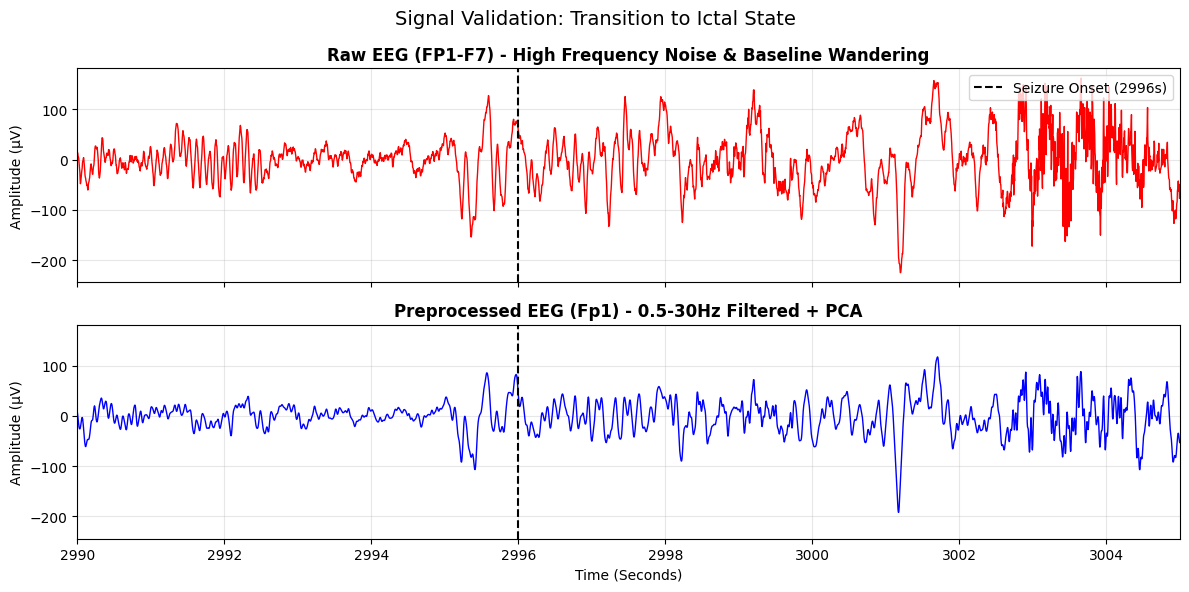

In [ ]:
import os
import mne
import matplotlib.pyplot as plt

def compare_artifact_removal(raw_path, prep_path, raw_channel, prep_channel, tmin, tmax):
    """Plots raw vs preprocessed EEG data accounting for MNE time-shifting."""

    # Load data
    raw_data = mne.io.read_raw_edf(raw_path, preload=True, verbose=False)
    prep_data = mne.io.read_raw_edf(prep_path, preload=True, verbose=False)

    # Pick the respective channels
    raw_data.pick_channels([raw_channel])
    prep_data.pick_channels([prep_channel])

    # Crop to the exact transition window
    raw_cropped = raw_data.crop(tmin=tmin, tmax=tmax)
    prep_cropped = prep_data.crop(tmin=tmin, tmax=tmax)

    # Get the arrays and time axes
    raw_sig, times = raw_cropped.get_data(return_times=True)
    prep_sig, _ = prep_cropped.get_data(return_times=True)

    # Convert from Volts to microVolts
    raw_sig = raw_sig[0] * 1e6
    prep_sig = prep_sig[0] * 1e6

    # Shift the MNE time array back to the absolute original timestamps
    times = times + tmin

    # --- Plotting ---
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)

    # Raw Plot
    axes[0].plot(times, raw_sig, color='red', linewidth=1)
    axes[0].set_title(f"Raw EEG ({raw_channel}) - High Frequency Noise & Baseline Wandering", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Amplitude (µV)")
    axes[0].axvline(x=2996, color='black', linestyle='--', label="Seizure Onset (2996s)")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)

    # Preprocessed Plot
    axes[1].plot(times, prep_sig, color='blue', linewidth=1)
    axes[1].set_title(f"Preprocessed EEG ({prep_channel}) - 0.5-30Hz Filtered + PCA", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Time (Seconds)")
    axes[1].set_ylabel("Amplitude (µV)")
    axes[1].axvline(x=2996, color='black', linestyle='--', label="Seizure Onset")
    axes[1].grid(True, alpha=0.3)

    # Strictly bound the X-axis to the 15-second window
    axes[0].set_xlim(tmin, tmax)

    plt.suptitle(f"Signal Validation: Transition to Ictal State", fontsize=14, y=0.98)
    plt.tight_layout()

    # Save the figure
    plt.savefig('Artifact_Removal_Validation.png', dpi=300)
    plt.show()

# --- Execution ---
patient = 'chb01'
original_file = 'chb01_03.edf'
preprocessed_file = 'seizures_chb01_03.edf'

raw_filepath = f'/chbmit/{patient}/{original_file}'
prep_filepath = f'/preprocessed_edf_path/{patient}/{preprocessed_file}'

# Pass 'FP1-F7' for raw, and 'Fp1' for the renamed preprocessed channel
if __name__ == "__main__":
    compare_artifact_removal(raw_filepath, prep_filepath, raw_channel='FP1-F7', prep_channel='Fp1', tmin=2990, tmax=3005)

## **4.3.2  Power Spectral Density**


/tmp/ipython-input-22-49877310.py:10: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_data = mne.io.read_raw_edf(raw_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


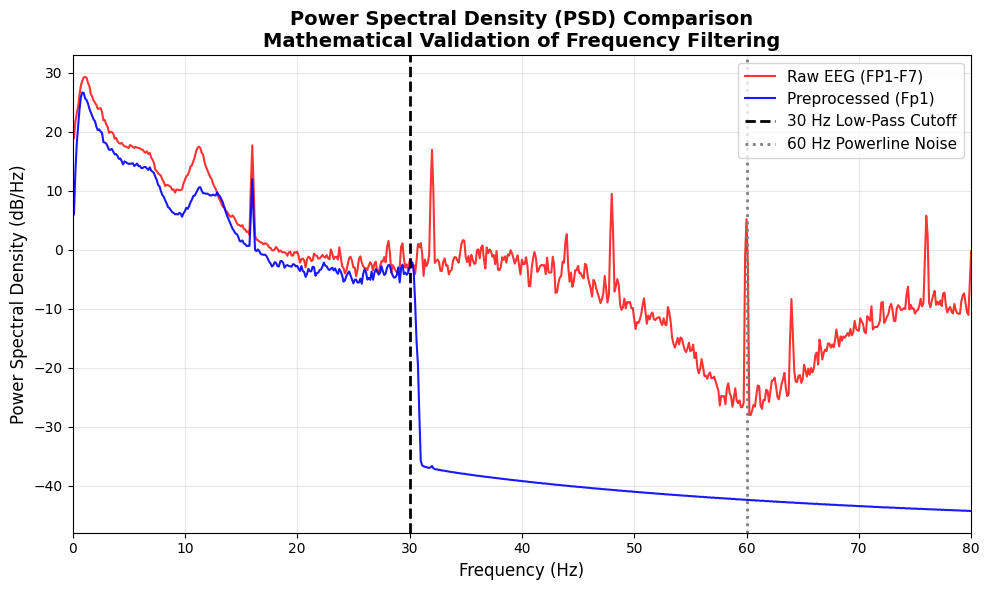

In [ ]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

def compare_psd(raw_path, prep_path, raw_channel, prep_channel):
    """Computes and plots the Power Spectral Density (PSD) using Welch's method."""

    # Load data
    raw_data = mne.io.read_raw_edf(raw_path, preload=True, verbose=False)
    prep_data = mne.io.read_raw_edf(prep_path, preload=True, verbose=False)

    # Pick the respective channels
    raw_data.pick_channels([raw_channel])
    prep_data.pick_channels([prep_channel])

    # Compute PSD using Welch's method
    # fmax=80 allows us to clearly see the 60 Hz powerline noise in the raw data
    raw_psd = raw_data.compute_psd(method='welch', fmin=0.1, fmax=80, n_fft=2048, verbose=False)
    prep_psd = prep_data.compute_psd(method='welch', fmin=0.1, fmax=80, n_fft=2048, verbose=False)

    # Extract power arrays and frequencies
    raw_psds, freqs = raw_psd.get_data(return_freqs=True)
    prep_psds, _ = prep_psd.get_data(return_freqs=True)

    # Convert Volts^2/Hz to microVolts^2/Hz, then to Decibels (dB) for standard academic plotting
    raw_psds_db = 10 * np.log10(raw_psds[0] * 1e12)
    prep_psds_db = 10 * np.log10(prep_psds[0] * 1e12)

    # --- Plotting ---
    plt.figure(figsize=(10, 6))

    # Plot the spectra
    plt.plot(freqs, raw_psds_db, color='red', label=f'Raw EEG ({raw_channel})', linewidth=1.5, alpha=0.8)
    plt.plot(freqs, prep_psds_db, color='blue', label=f'Preprocessed ({prep_channel})', linewidth=1.5, alpha=0.9)

    # Highlight the filtering thresholds
    plt.axvline(x=30, color='black', linestyle='--', linewidth=2, label='30 Hz Low-Pass Cutoff')
    plt.axvline(x=60, color='gray', linestyle=':', linewidth=2, label='60 Hz Powerline Noise')

    # Formatting
    plt.title("Power Spectral Density (PSD) Comparison\nMathematical Evaluation of Frequency Filtering", fontsize=14, fontweight='bold')
    plt.xlabel("Frequency (Hz)", fontsize=12)
    plt.ylabel("Power Spectral Density (dB/Hz)", fontsize=12)
    plt.legend(loc="upper right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 80)

    plt.tight_layout()
    plt.savefig('PSD_Artifact_Removal.png', dpi=300)
    plt.show()

# --- Execution ---
patient = 'chb01'
original_file = 'chb01_03.edf'
preprocessed_file = 'seizures_chb01_03.edf'

raw_filepath = f'/chbmit/{patient}/{original_file}'
prep_filepath = f'/preprocessed_edf_path/{patient}/{preprocessed_file}'

# Run the comparison
if __name__ == "__main__":
    compare_psd(raw_filepath, prep_filepath, raw_channel='FP1-F7', prep_channel='Fp1')

## **4.4.3 PCA Variance Analysis: Evaluating Potential Interference Components**


/tmp/ipython-input-8-4185606570.py:49: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data_raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)


Channels retained for PCA: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'P4', 'P8', 'O1', 'O2']


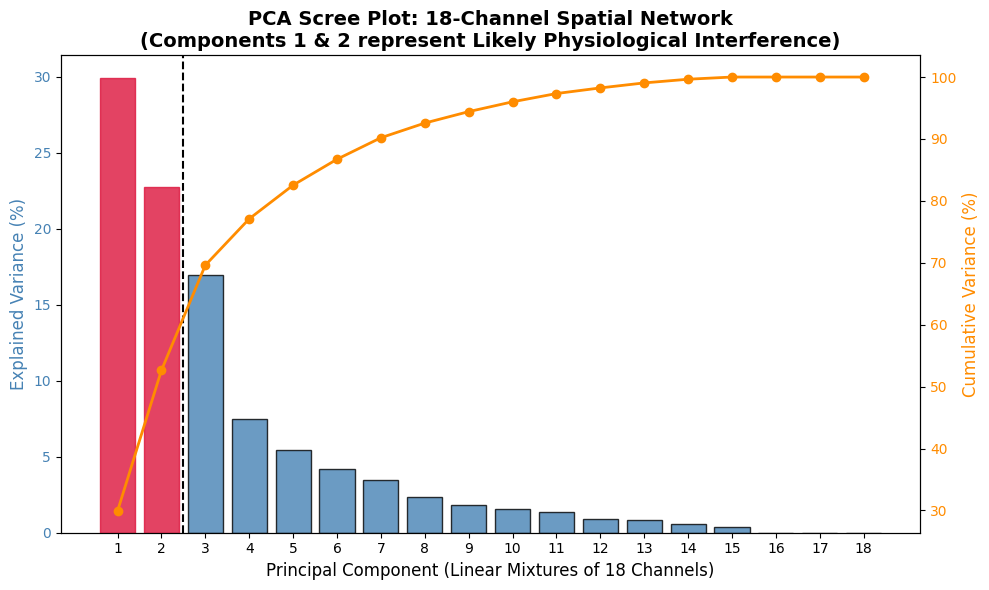

In [ ]:
import mne
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path

#  Define the exact channel lists from utils.py
standard_channel_order = [
    "FP1-F7", "F7-T7", "T7-P7", "P7-O1", "FP1-F3", "F3-C3", "C3-P3",
    "P3-O1", "FZ-CZ", "CZ-PZ", "FP2-F4", "F4-C4", "C4-P4", "P4-O2",
    "FP2-F8", "F8-T8", "T8-P8-0", "P8-O2"
]

current_order = [
    "Fp1", "F7", "T7", "P7", "F3", "C3", "P3", "O1", "Fz",
    "Cz", "Fp2", "F4", "C4", "P4", "O2", "F8", "P8", "T8"
]

ch_demanded_order = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "T7", "C3",
    "Cz", "C4", "T8", "P7", "P3", "P4", "P8", "O1", "O2"
]

# Replicate the stripping logic from utils.py
def remove_channels_dummy(ch_name):
    if re.findall("--", ch_name) or re.findall("\.", ch_name):
        return True
    return False

def remove_channels_duplicate(ch_name):
    ch_decomposed = ch_name.split(sep="-")
    if len(ch_decomposed) > 2:
        if int(ch_decomposed[-1]) != 0:
            return True
    return False

def remove_repeating_pairs(cleared_ch_names):
    repeating_chs = []
    for i, pair in enumerate(cleared_ch_names):
        for pair_2 in cleared_ch_names[i + 1 :]:
            if set(pair.split("-")) == set(pair_2.split("-")):
                repeating_chs.append(pair_2)
                break
    return repeating_chs[0] if repeating_chs else None

def load_and_dump_channels(filepath):
    """Reads CHB-MIT file and resets the order of channels."""
    data_raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)

    # Drop dummy channels
    ch_to_remove = list(filter(remove_channels_dummy, data_raw.ch_names))
    if ch_to_remove: data_raw.drop_channels(ch_to_remove)

    # Drop duplicate channels
    ch_to_remove = list(filter(remove_channels_duplicate, data_raw.ch_names))
    if ch_to_remove: data_raw.drop_channels(ch_to_remove)

    # Drop repeating pairs
    rep_pair = remove_repeating_pairs(data_raw.ch_names)
    if rep_pair: data_raw.drop_channels(rep_pair)

    # Keep only standard channels
    for channel in data_raw.ch_names:
        if channel not in standard_channel_order:
            data_raw.drop_channels(channel)

    if data_raw.ch_names != standard_channel_order:
        data_raw.reorder_channels(standard_channel_order)

    if len(data_raw.ch_names) < 18:
        print(f"Too few channels: {len(data_raw.ch_names)}")
        return None

    return data_raw

def reorder_channels_chbmit(raw):
    """Reorders the channels of chbmit dataset patients."""
    ch_map = {}
    for n, old_name in enumerate(raw.ch_names):
        ch_map[old_name] = current_order[n]
    raw.rename_channels(ch_map)
    raw.reorder_channels(ch_demanded_order)
    return raw

# 3. Main Plotting Function
def plot_pca_scree(raw_path, tmin, tmax):
    """Calculates and plots the explained variance of PCA components."""

    # Unify and strip channels
    raw = load_and_dump_channels(raw_path)
    if raw is None:
        return
    raw = reorder_channels_chbmit(raw)

    print(f"Channels retained for PCA: {raw.ch_names}")

    # Crop and filter
    raw.crop(tmin=tmin, tmax=tmax)
    raw.filter(l_freq=0.5, h_freq=30.0, verbose=False)

    # Extract 18xN data matrix and fit PCA
    data = raw.get_data()
    pca = PCA()
    pca.fit(data)

    variance_ratios = pca.explained_variance_ratio_ * 100
    cumulative_variance = np.cumsum(variance_ratios)
    components = np.arange(1, len(variance_ratios) + 1)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    bars = ax1.bar(components, variance_ratios, color='steelblue', alpha=0.8, edgecolor='black', label='Individual Variance')
    ax1.set_xlabel('Principal Component (Linear Mixtures of 18 Channels)', fontsize=12)
    ax1.set_ylabel('Explained Variance (%)', fontsize=12, color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    # Highlight discarded components
    bars[0].set_color('crimson')
    bars[1].set_color('crimson')

    ax2 = ax1.twinx()
    ax2.plot(components, cumulative_variance, color='darkorange', marker='o', linewidth=2, label='Cumulative Variance')
    ax2.set_ylabel('Cumulative Variance (%)', fontsize=12, color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    plt.title('PCA Scree Plot: 18-Channel Spatial Network\n(Components 1 & 2 represent Likely Physiological Interference)', fontsize=14, fontweight='bold')
    ax1.set_xticks(components)
    ax1.axvline(x=2.5, color='black', linestyle='--', linewidth=1.5, label='Discard Cutoff')

    fig.tight_layout()
    plt.savefig('PCA_Variance_18Channels.png', dpi=300)
    plt.show()

# --- Execution ---
patient = 'chb01'
original_file = 'chb01_03.edf'
# Update the path to specific environment
raw_filepath = f'/chbmit/{patient}/{original_file}'

# Execution with a 60-second window containing the seizure
if __name__ == "__main__":
    plot_pca_scree(raw_filepath, tmin=2950, tmax=3010)

##

## **4.4.4 Quantitative Noise Reduction: RMS Amplitude Analysis**


In [ ]:
import mne
import numpy as np

def calculate_rms_reduction(raw_path, prep_path, raw_channel, prep_channel, tmin, tmax):
    """Calculates the RMS amplitude to quantify baseline noise reduction."""

    # Load data
    raw_data = mne.io.read_raw_edf(raw_path, preload=True, verbose=False)
    prep_data = mne.io.read_raw_edf(prep_path, preload=True, verbose=False)

    # Pick channels
    raw_data.pick_channels([raw_channel])
    prep_data.pick_channels([prep_channel])

    # Crop to an INTER-ICTAL (quiet) window
    raw_cropped = raw_data.crop(tmin=tmin, tmax=tmax)
    prep_cropped = prep_data.crop(tmin=tmin, tmax=tmax)

    # Extract data arrays and convert to microVolts (µV)
    raw_sig = raw_cropped.get_data()[0] * 1e6
    prep_sig = prep_cropped.get_data()[0] * 1e6

    # Calculate Root Mean Square (RMS)
    rms_raw = np.sqrt(np.mean(raw_sig**2))
    rms_prep = np.sqrt(np.mean(prep_sig**2))

    # Calculate percentage reduction
    reduction_pct = ((rms_raw - rms_prep) / rms_raw) * 100

    # --- Output formatting for thesis ---
    print("--- Quantitative Noise Reduction (Inter-Ictal Window) ---")
    print(f"File: {os.path.basename(raw_path)}")
    print(f"Channel: {raw_channel} -> {prep_channel}")
    print(f"Time Window: {tmin}s to {tmax}s (Quiet / Inter-Ictal)\n")
    print(f"Raw RMS Amplitude:          {rms_raw:.2f} µV")
    print(f"Preprocessed RMS Amplitude: {rms_prep:.2f} µV")
    print(f"Total Noise Attenuation:    {reduction_pct:.2f}%")

    return rms_raw, rms_prep, reduction_pct

# --- Execution ---
import os
patient = 'chb01'
original_file = 'chb01_03.edf'
preprocessed_file = 'seizures_chb01_03.edf'

raw_filepath = f'/chbmit/{patient}/{original_file}'
prep_filepath = f'/preprocessed_edf_path/{patient}/{preprocessed_file}'

# Evaluate the first 60 seconds of the file (long before the seizure at 2996s)
if __name__ == "__main__":
    calculate_rms_reduction(raw_filepath, prep_filepath, raw_channel='FP1-F7', prep_channel='Fp1', tmin=0, tmax=60)

/tmp/ipython-input-33-3861387012.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_data = mne.io.read_raw_edf(raw_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
--- Quantitative Noise Reduction (Inter-Ictal Window) ---
File: chb01_03.edf
Channel: FP1-F7 -> Fp1
Time Window: 0s to 60s (Quiet / Inter-Ictal)

Raw RMS Amplitude:          39.41 µV
Preprocessed RMS Amplitude: 24.69 µV
Total Noise Attenuation:    37.35%


(39.408624171843805, 24.687751542783932, 37.35444446085855)

## **4.4.5 Tri-State Morphological Comparison**


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


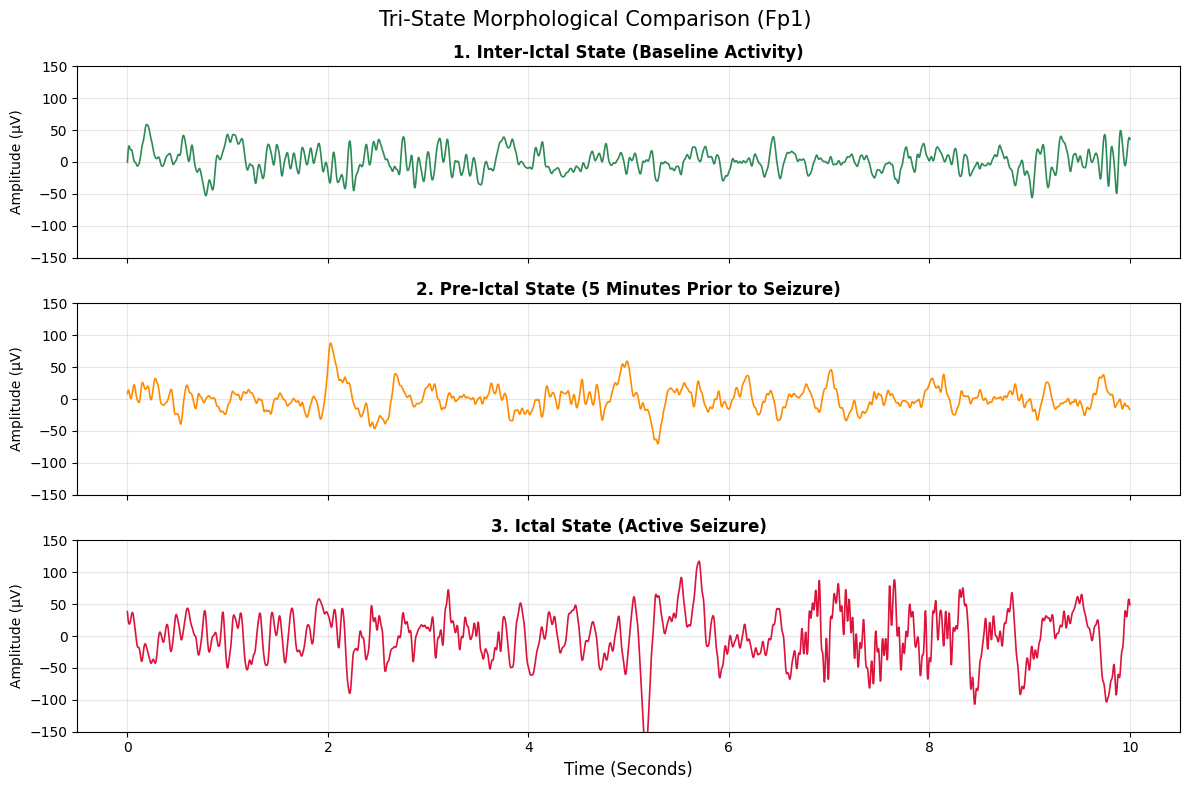

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

def plot_tristate_morphology(prep_path, channel, t_inter, t_pre, t_ictal, window_size=10):
    """Plots a 3-panel comparison of Inter-ictal, Pre-ictal, and Ictal EEG states."""

    # Load the preprocessed continuous EDF
    raw = mne.io.read_raw_edf(prep_path, preload=True, verbose=False)
    raw.pick_channels([channel])

    # Crop the 10-second windows for each state
    inter_raw = raw.copy().crop(tmin=t_inter, tmax=t_inter + window_size)
    pre_raw = raw.copy().crop(tmin=t_pre, tmax=t_pre + window_size)
    ictal_raw = raw.copy().crop(tmin=t_ictal, tmax=t_ictal + window_size)

    # Extract data and convert to microVolts
    inter_sig = inter_raw.get_data()[0] * 1e6
    pre_sig = pre_raw.get_data()[0] * 1e6
    ictal_sig = ictal_raw.get_data()[0] * 1e6

    # Create an artificial 10-second time axis for clean side-by-side comparison
    times = np.linspace(0, window_size, len(inter_sig))

    # --- Plotting ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=True)

    # Panel 1: Inter-ictal
    axes[0].plot(times, inter_sig, color='seagreen', linewidth=1.2)
    axes[0].set_title("1. Inter-Ictal State (Baseline Activity)", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Amplitude (µV)")
    axes[0].grid(True, alpha=0.3)

    # Panel 2: Pre-ictal
    axes[1].plot(times, pre_sig, color='darkorange', linewidth=1.2)
    axes[1].set_title("2. Pre-Ictal State (5 Minutes Prior to Seizure)", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Amplitude (µV)")
    axes[1].grid(True, alpha=0.3)

    # Panel 3: Ictal
    axes[2].plot(times, ictal_sig, color='crimson', linewidth=1.2)
    axes[2].set_title("3. Ictal State (Active Seizure)", fontsize=12, fontweight='bold')
    axes[2].set_xlabel("Time (Seconds)", fontsize=12)
    axes[2].set_ylabel("Amplitude (µV)")
    axes[2].grid(True, alpha=0.3)

    # Set identical Y-limits to emphasize the massive amplitude shift during the seizure
    axes[0].set_ylim(-150, 150)

    plt.suptitle(f"Tri-State Morphological Comparison ({channel})", fontsize=15, y=0.98)
    plt.tight_layout()
    plt.savefig('Tri_State_Comparison.png', dpi=300)
    plt.show()

# --- Execution ---
patient = 'chb01'
preprocessed_file = 'seizures_chb01_03.edf'
prep_filepath = f'/preprocessed_edf_path/{patient}/{preprocessed_file}'

# Fp1 is a great channel to show these transitions.
# t_inter = 0s, t_pre = 2696s (5 mins before onset), t_ictal = 2996s (onset)
if __name__ == "__main__":
    plot_tristate_morphology(prep_filepath, channel='Fp1', t_inter=0, t_pre=2696, t_ictal=2996)

## **4.4.6 Spatial Voltage Topographic Maps** 


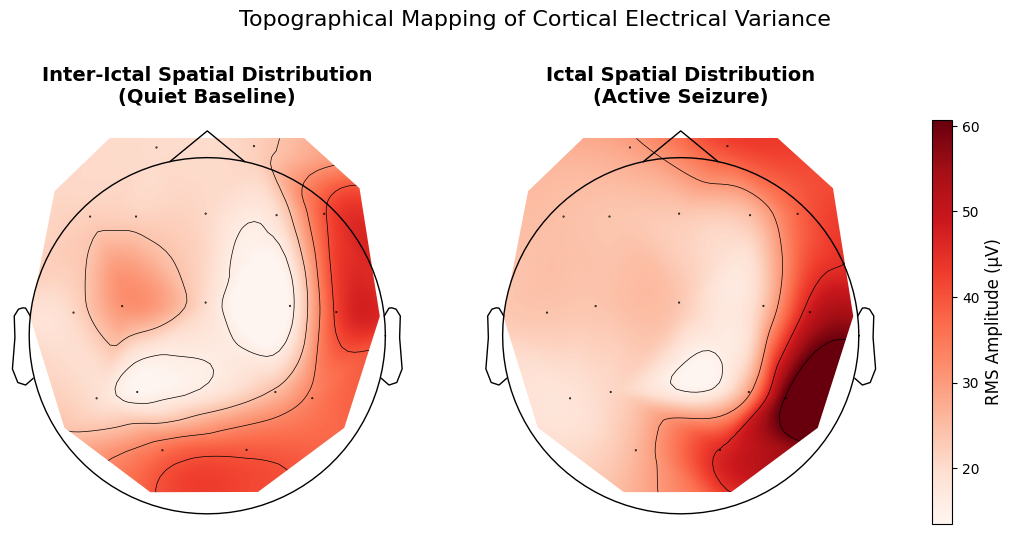

In [ ]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

def plot_spatial_topomaps(prep_path, t_inter, t_ictal, window_size=5):
    """Plots spatial topographic maps of EEG variance (Inter-ictal vs. Ictal)."""

    # Load the preprocessed data
    raw = mne.io.read_raw_edf(prep_path, preload=True, verbose=False)

    # Apply the standard 10-20 montage
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage)

    # Crop the data into our two states
    inter_raw = raw.copy().crop(tmin=t_inter, tmax=t_inter + window_size)
    ictal_raw = raw.copy().crop(tmin=t_ictal, tmax=t_ictal + window_size)

    # Extract data and calculate the Root Mean Square (RMS) amplitude per channel
    inter_data = inter_raw.get_data() * 1e6  # Convert to microVolts
    ictal_data = ictal_raw.get_data() * 1e6

    rms_inter = np.sqrt(np.mean(inter_data**2, axis=1))
    rms_ictal = np.sqrt(np.mean(ictal_data**2, axis=1))

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Calculate shared limits for the color scale
    vmin = min(rms_inter.min(), rms_ictal.min())
    vmax = max(rms_inter.max(), rms_ictal.max())

    # Panel 1: Inter-ictal Topomap
    # FIX: Replaced vmin/vmax with vlim=(vmin, vmax)
    im_inter, _ = mne.viz.plot_topomap(
        rms_inter, inter_raw.info, axes=axes[0], show=False,
        vlim=(vmin, vmax), cmap='Reds', contours=4, extrapolate='local'
    )
    axes[0].set_title(f"Inter-Ictal Spatial Distribution\n(Quiet Baseline)", fontsize=14, fontweight='bold')

    # Panel 2: Ictal Topomap
    # FIX: Replaced vmin/vmax with vlim=(vmin, vmax)
    im_ictal, _ = mne.viz.plot_topomap(
        rms_ictal, ictal_raw.info, axes=axes[1], show=False,
        vlim=(vmin, vmax), cmap='Reds', contours=4, extrapolate='local'
    )
    axes[1].set_title(f"Ictal Spatial Distribution\n(Active Seizure)", fontsize=14, fontweight='bold')

    # Add a shared colorbar
    cbar = fig.colorbar(im_ictal, ax=axes, orientation='vertical', shrink=0.8, pad=0.05)
    cbar.set_label('RMS Amplitude (µV)', fontsize=12)

    plt.suptitle("Topographical Mapping of Cortical Electrical Variance", fontsize=16, y=1.05)
    plt.savefig('Spatial_Topomaps.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- Execution ---
patient = 'chb01'
preprocessed_file = 'seizures_chb01_03.edf'
prep_filepath = f'/preprocessed_edf_path/{patient}/{preprocessed_file}'

# Run the comparison
if __name__ == "__main__":
    plot_spatial_topomaps(prep_filepath, t_inter=0, t_ictal=2996, window_size=5)

## **4.4.7 Channel-Wise Variance Bar Chart**

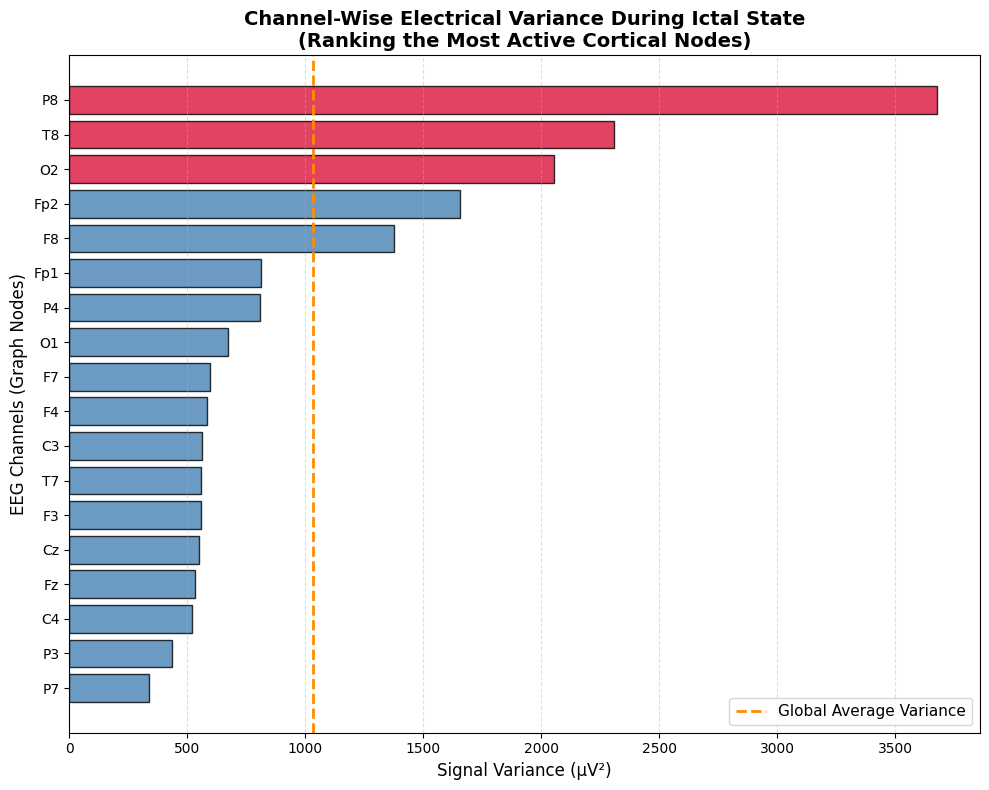

In [ ]:
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_channel_variance(prep_path, t_ictal, window_size=5):
    """Calculates and plots the variance of each channel during an active seizure."""

    # Load the preprocessed data
    raw = mne.io.read_raw_edf(prep_path, preload=True, verbose=False)

    # Crop to the active seizure window
    ictal_raw = raw.copy().crop(tmin=t_ictal, tmax=t_ictal + window_size)

    # Extract data in microVolts and get channel names
    data = ictal_raw.get_data() * 1e6
    channels = ictal_raw.ch_names

    # Calculate the variance for each channel (row-wise)
    variances = np.var(data, axis=1)

    # Create a DataFrame to sort the channels
    df = pd.DataFrame({'Channel': channels, 'Variance': variances})
    # Sort ascending so the highest variance is at the top of the horizontal bar chart
    df = df.sort_values(by='Variance', ascending=True)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 8))

    # Highlight the top 3 most active channels in red, the rest in blue
    colors = ['steelblue' if i < (len(df) - 3) else 'crimson' for i in range(len(df))]

    bars = ax.barh(df['Channel'], df['Variance'], color=colors, edgecolor='black', alpha=0.8)

    # Formatting
    ax.set_title("Channel-Wise Electrical Variance During Ictal State\n(Ranking the Most Active Cortical Nodes)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Signal Variance (µV²)", fontsize=12)
    ax.set_ylabel("EEG Channels (Graph Nodes)", fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Add a vertical line for the average variance across all 18 channels
    avg_var = df['Variance'].mean()
    ax.axvline(x=avg_var, color='darkorange', linestyle='--', linewidth=2, label=f'Global Average Variance')
    ax.legend(loc='lower right', fontsize=11)

    plt.tight_layout()
    plt.savefig('Channel_Variance_Ranking.png', dpi=300)
    plt.show()

# --- Execution ---
patient = 'chb01'
preprocessed_file = 'seizures_chb01_03.edf'
prep_filepath = f'/preprocessed_edf_path/{patient}/{preprocessed_file}'

# t_ictal = 2996s (seizure onset), analyzing the first 5 seconds of the seizure
if __name__ == "__main__":
    plot_channel_variance(prep_filepath, t_ictal=2996, window_size=5)

## **4.5.1 Introduction to Graph-Based Representation**


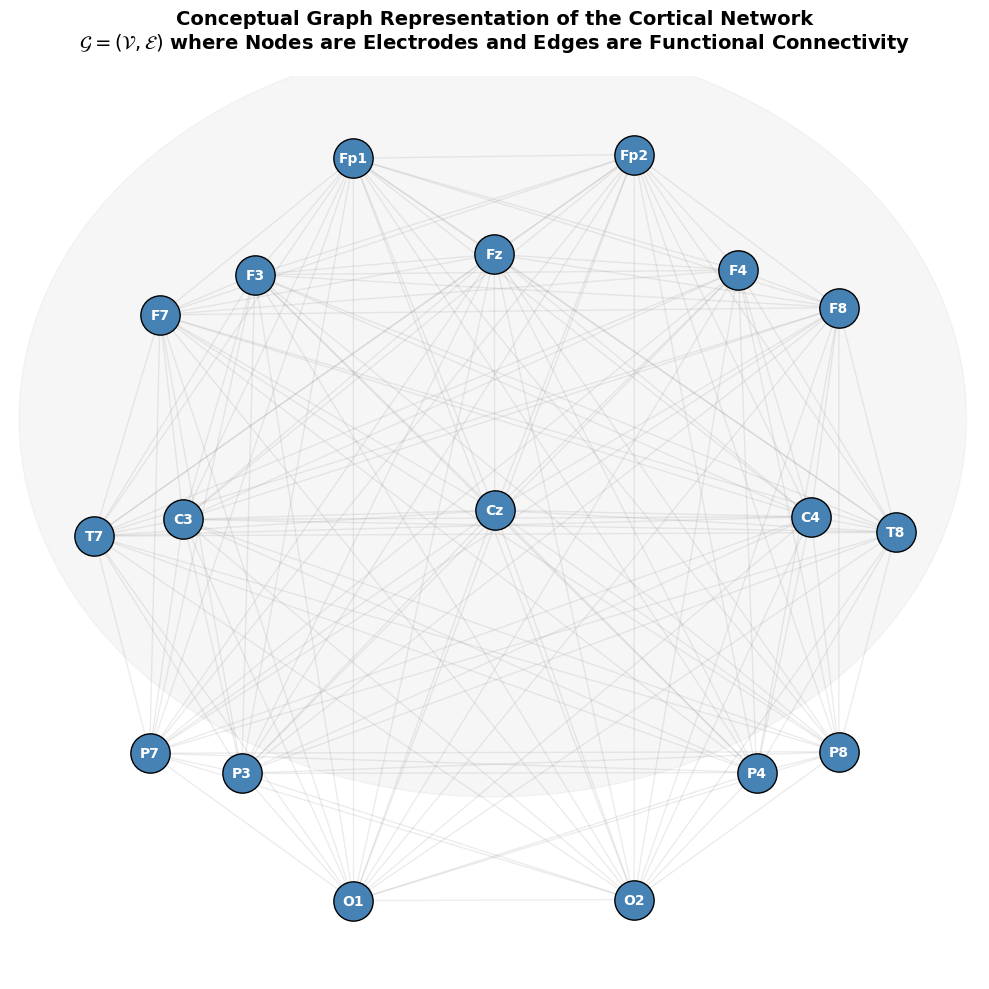

In [ ]:
import mne
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def plot_gnn_conceptual_graph():
    """Generates a conceptual top-down view of the 18 EEG channels as a mathematical graph."""

    # The exact 18 channels mapped in preprocessing pipeline
    channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
                'T7', 'C3', 'Cz', 'C4', 'T8',
                'P7', 'P3', 'P4', 'P8', 'O1', 'O2']

    # Load standard 10-20 montage to get real anatomical coordinates
    montage = mne.channels.make_standard_montage('standard_1020')
    pos_3d = montage.get_positions()['ch_pos']

    # Extract X and Y coordinates for a top-down 2D layout
    pos_2d = {ch: (pos_3d[ch][0], pos_3d[ch][1]) for ch in channels}

    # Initialize a NetworkX Graph
    G = nx.Graph()
    G.add_nodes_from(channels)

    # Create edges to make a FULLY CONNECTED graph
    # By removing the threshold distance check, every node connects to every other node
    for ch1 in channels:
        for ch2 in channels:
            if ch1 != ch2:
                G.add_edge(ch1, ch2)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 10))

    # Draw the mathematical edges (lines)
    # Reduced alpha to 0.15 and width to 1.0 so the 153 overlapping edges look clean
    nx.draw_networkx_edges(G, pos_2d, ax=ax, edge_color='gray', alpha=0.15, width=1.0)

    # Draw the nodes (electrodes)
    nx.draw_networkx_nodes(G, pos_2d, ax=ax, node_color='steelblue', node_size=800, edgecolors='black')

    # Draw the node labels (channel names)
    nx.draw_networkx_labels(G, pos_2d, ax=ax, font_size=10, font_weight='bold', font_color='white')

    # Formatting to make it look like a top-down head view
    ax.set_title("Conceptual Graph Representation of the Cortical Network\n$\mathcal{G} = (\mathcal{V}, \mathcal{E})$ where Nodes are Electrodes and Edges are Functional Connectivity",
                 fontsize=14, fontweight='bold', pad=20)

    # Remove standard axes for a cleaner geometric look
    ax.axis('off')

    # Add a subtle background circle to imply the shape of a head
    head_circle = plt.Circle((0, 0.015), 0.1, color='lightgray', alpha=0.2, zorder=0)
    ax.add_patch(head_circle)

    plt.tight_layout()
    plt.savefig('Graph_Representation_Concept.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    plot_gnn_conceptual_graph()

## **4.5.2 Temporal Windowing and Sample Extraction**


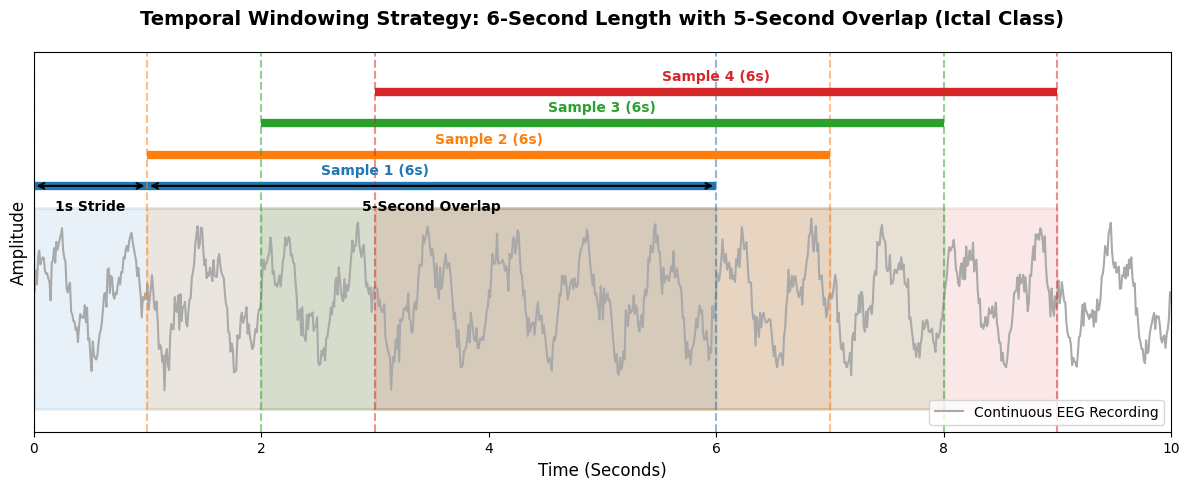

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_temporal_windowing():
    """Generates a diagram illustrating the 6-second window and 5-second overlap strategy."""

    # Create a simulated "continuous EEG signal"
    time = np.linspace(0, 10, 1000)
    # A mix of low and high frequencies to look like a brainwave
    signal = np.sin(2 * np.pi * 1.5 * time) + 0.5 * np.sin(2 * np.pi * 5 * time) + np.random.normal(0, 0.2, len(time))

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot the continuous signal
    ax.plot(time, signal, color='darkgray', linewidth=1.5, label="Continuous EEG Recording")

    # Define window parameters
    window_length = 6
    overlap = 5
    stride = window_length - overlap # 1 second

    # Draw the sliding windows as colored blocks
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Distinct colors for overlap clarity
    y_offsets = [2.5, 3.2, 3.9, 4.6] # Stack them visually so the overlap is obvious

    for i in range(4):
        start_time = i * stride
        end_time = start_time + window_length

        # Draw a semi-transparent rectangle over the signal to show extraction
        rect = patches.Rectangle((start_time, -2.5), window_length, 4.5,
                                 linewidth=2, edgecolor=colors[i], facecolor=colors[i], alpha=0.1)
        ax.add_patch(rect)

        # Draw a solid horizontal bar above to represent the extracted tensor/sample
        ax.hlines(y=y_offsets[i], xmin=start_time, xmax=end_time, color=colors[i], linewidth=6)

        # Add labels to the extracted samples
        ax.text(start_time + (window_length/2), y_offsets[i] + 0.2, f"Sample {i+1} (6s)",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=colors[i])

        # Add vertical dashed lines to show the exact start/stop cuts
        ax.axvline(x=start_time, color=colors[i], linestyle='--', alpha=0.5)
        ax.axvline(x=end_time, color=colors[i], linestyle='--', alpha=0.5)

    # Formatting the diagram
    ax.set_title("Temporal Windowing Strategy: 6-Second Length with 5-Second Overlap (Ictal Class)", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Time (Seconds)", fontsize=12)
    ax.set_ylabel("Amplitude", fontsize=12)
    ax.set_xlim(0, 10)
    ax.set_ylim(-3, 5.5)

    # Add a marker to explicitly show the 5-second overlap between Sample 1 and 2
    ax.annotate('', xy=(1, 2.5), xytext=(6, 2.5),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(3.5, 2.2, '5-Second Overlap', ha='center', va='top', fontsize=10, fontweight='bold')

    # Add a marker to show the 1-second stride
    ax.annotate('', xy=(0, 2.5), xytext=(1, 2.5),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(0.5, 2.2, '1s Stride', ha='center', va='top', fontsize=10, fontweight='bold')

    # Remove Y-axis ticks as amplitude is conceptual here
    ax.set_yticks([])
    ax.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig('Temporal_Windowing_Strategy.png', dpi=300)
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    plot_temporal_windowing()

In [ ]:
import os
import torch
import numpy as np

def calculate_class_distribution(pt_dir):
    """Calculates the exact number of samples per class and their ratios from .pt files."""
    # 0: Pre-ictal, 1: Ictal, 2: Inter-ictal (based on dataloader_utils.py DEFAULT_CLASS_LABELS)
    class_counts = {0: 0, 1: 0, 2: 0}
    total_samples = 0

    # Iterate over all .pt files in the directory
    for file in os.listdir(pt_dir):
        if file.endswith('.pt'):
            filepath = os.path.join(pt_dir, file)

            # Load the collated data
            data, slices = torch.load(filepath, weights_only=False)

            # The labels are stored in data.y
            labels = data.y.numpy().flatten()

            # Count occurrences
            unique, counts = np.unique(labels, return_counts=True)
            for val, count in zip(unique, counts):
                class_counts[int(val)] += count
                total_samples += count

    print("--- Dataset Class Distribution ---")
    print(f"Total Samples:   {total_samples}")
    print(f"Pre-ictal (0):   {class_counts[0]}")
    print(f"Ictal (1):       {class_counts[1]}")
    print(f"Inter-ictal (2): {class_counts[2]}")

    # Calculate ratios relative to the Ictal class (the minority)
    if class_counts[1] > 0:
        pre_ratio = class_counts[0] / class_counts[1]
        inter_ratio = class_counts[2] / class_counts[1]
        print("\n--- Approximate Ratios ---")
        print(f"Ictal : Pre-ictal   = 1 : {pre_ratio:.2f}")
        print(f"Ictal : Inter-ictal = 1 : {inter_ratio:.2f}")
    else:
        print("No Ictal samples found to compute ratio.")

# --- Execution ---
# Point this to saved .pt files
if __name__ == "__main__":
    pt_directory = '/cache/train'
    calculate_class_distribution(pt_directory)

--- Dataset Class Distribution ---
Total Samples:   35982
Pre-ictal (0):   13603
Ictal (1):       9101
Inter-ictal (2): 13278

--- Approximate Ratios ---
Ictal : Pre-ictal   = 1 : 1.49
Ictal : Inter-ictal = 1 : 1.46


## **4.5.3 Feature Engineering: Extracting Node Characteristics**


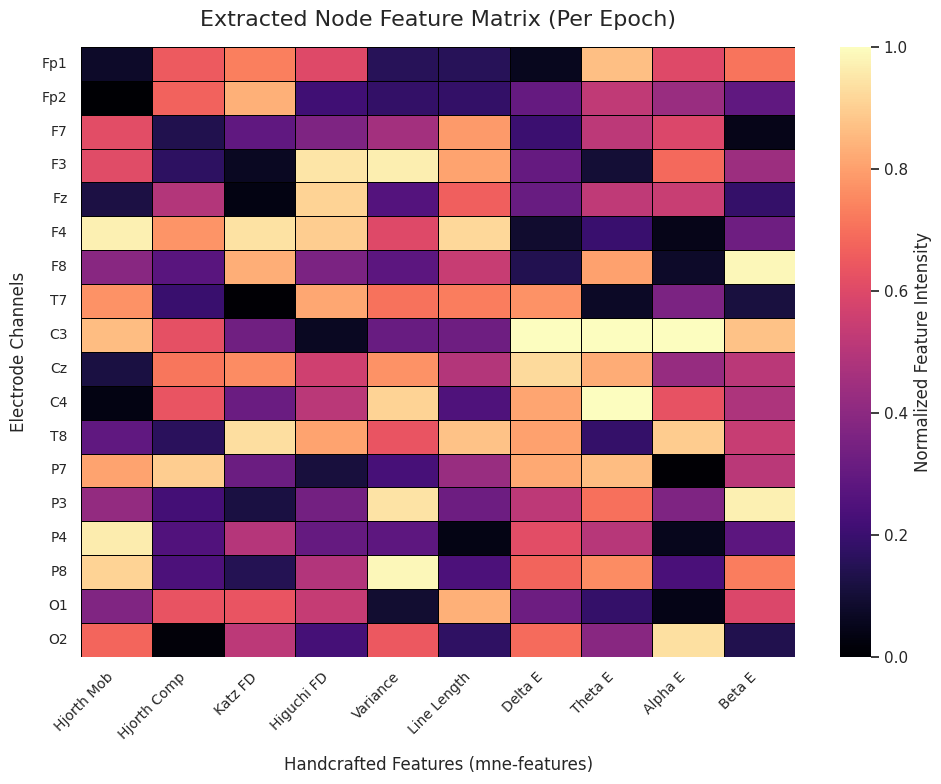

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the 18 channels and the extracted features
channels = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "T7",
    "C3", "Cz", "C4", "T8", "P7", "P3", "P4", "P8", "O1", "O2"
]
features = [
    "Hjorth Mob", "Hjorth Comp", "Katz FD", "Higuchi FD",
    "Variance", "Line Length", "Delta E", "Theta E", "Alpha E", "Beta E"
]

# Generate synthetic normalized data to represent the feature matrix
np.random.seed(42)
feature_matrix = np.random.rand(len(channels), len(features))

# Add some artificial "structure" so it looks like real regional brain data
feature_matrix[8:11, 6:10] += 0.4  # Boost central spectral energy
feature_matrix[0:2, 0:2] -= 0.3    # Lower frontal Hjorth mobility
feature_matrix = np.clip(feature_matrix, 0, 1)

# Set up the plot aesthetics
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Create the heatmap
ax = sns.heatmap(
    feature_matrix,
    cmap="magma", # 'magma' or 'viridis' look very professional for scientific data
    xticklabels=features,
    yticklabels=channels,
    cbar_kws={'label': 'Normalized Feature Intensity'},
    linewidths=0.5,
    linecolor='black'
)

# Customize titles and labels
plt.title("Extracted Node Feature Matrix (Per Epoch)", fontsize=16, pad=15)
plt.xlabel("Handcrafted Features (mne-features)", fontsize=12, labelpad=10)
plt.ylabel("Electrode Channels", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

Extracting features from tensors...


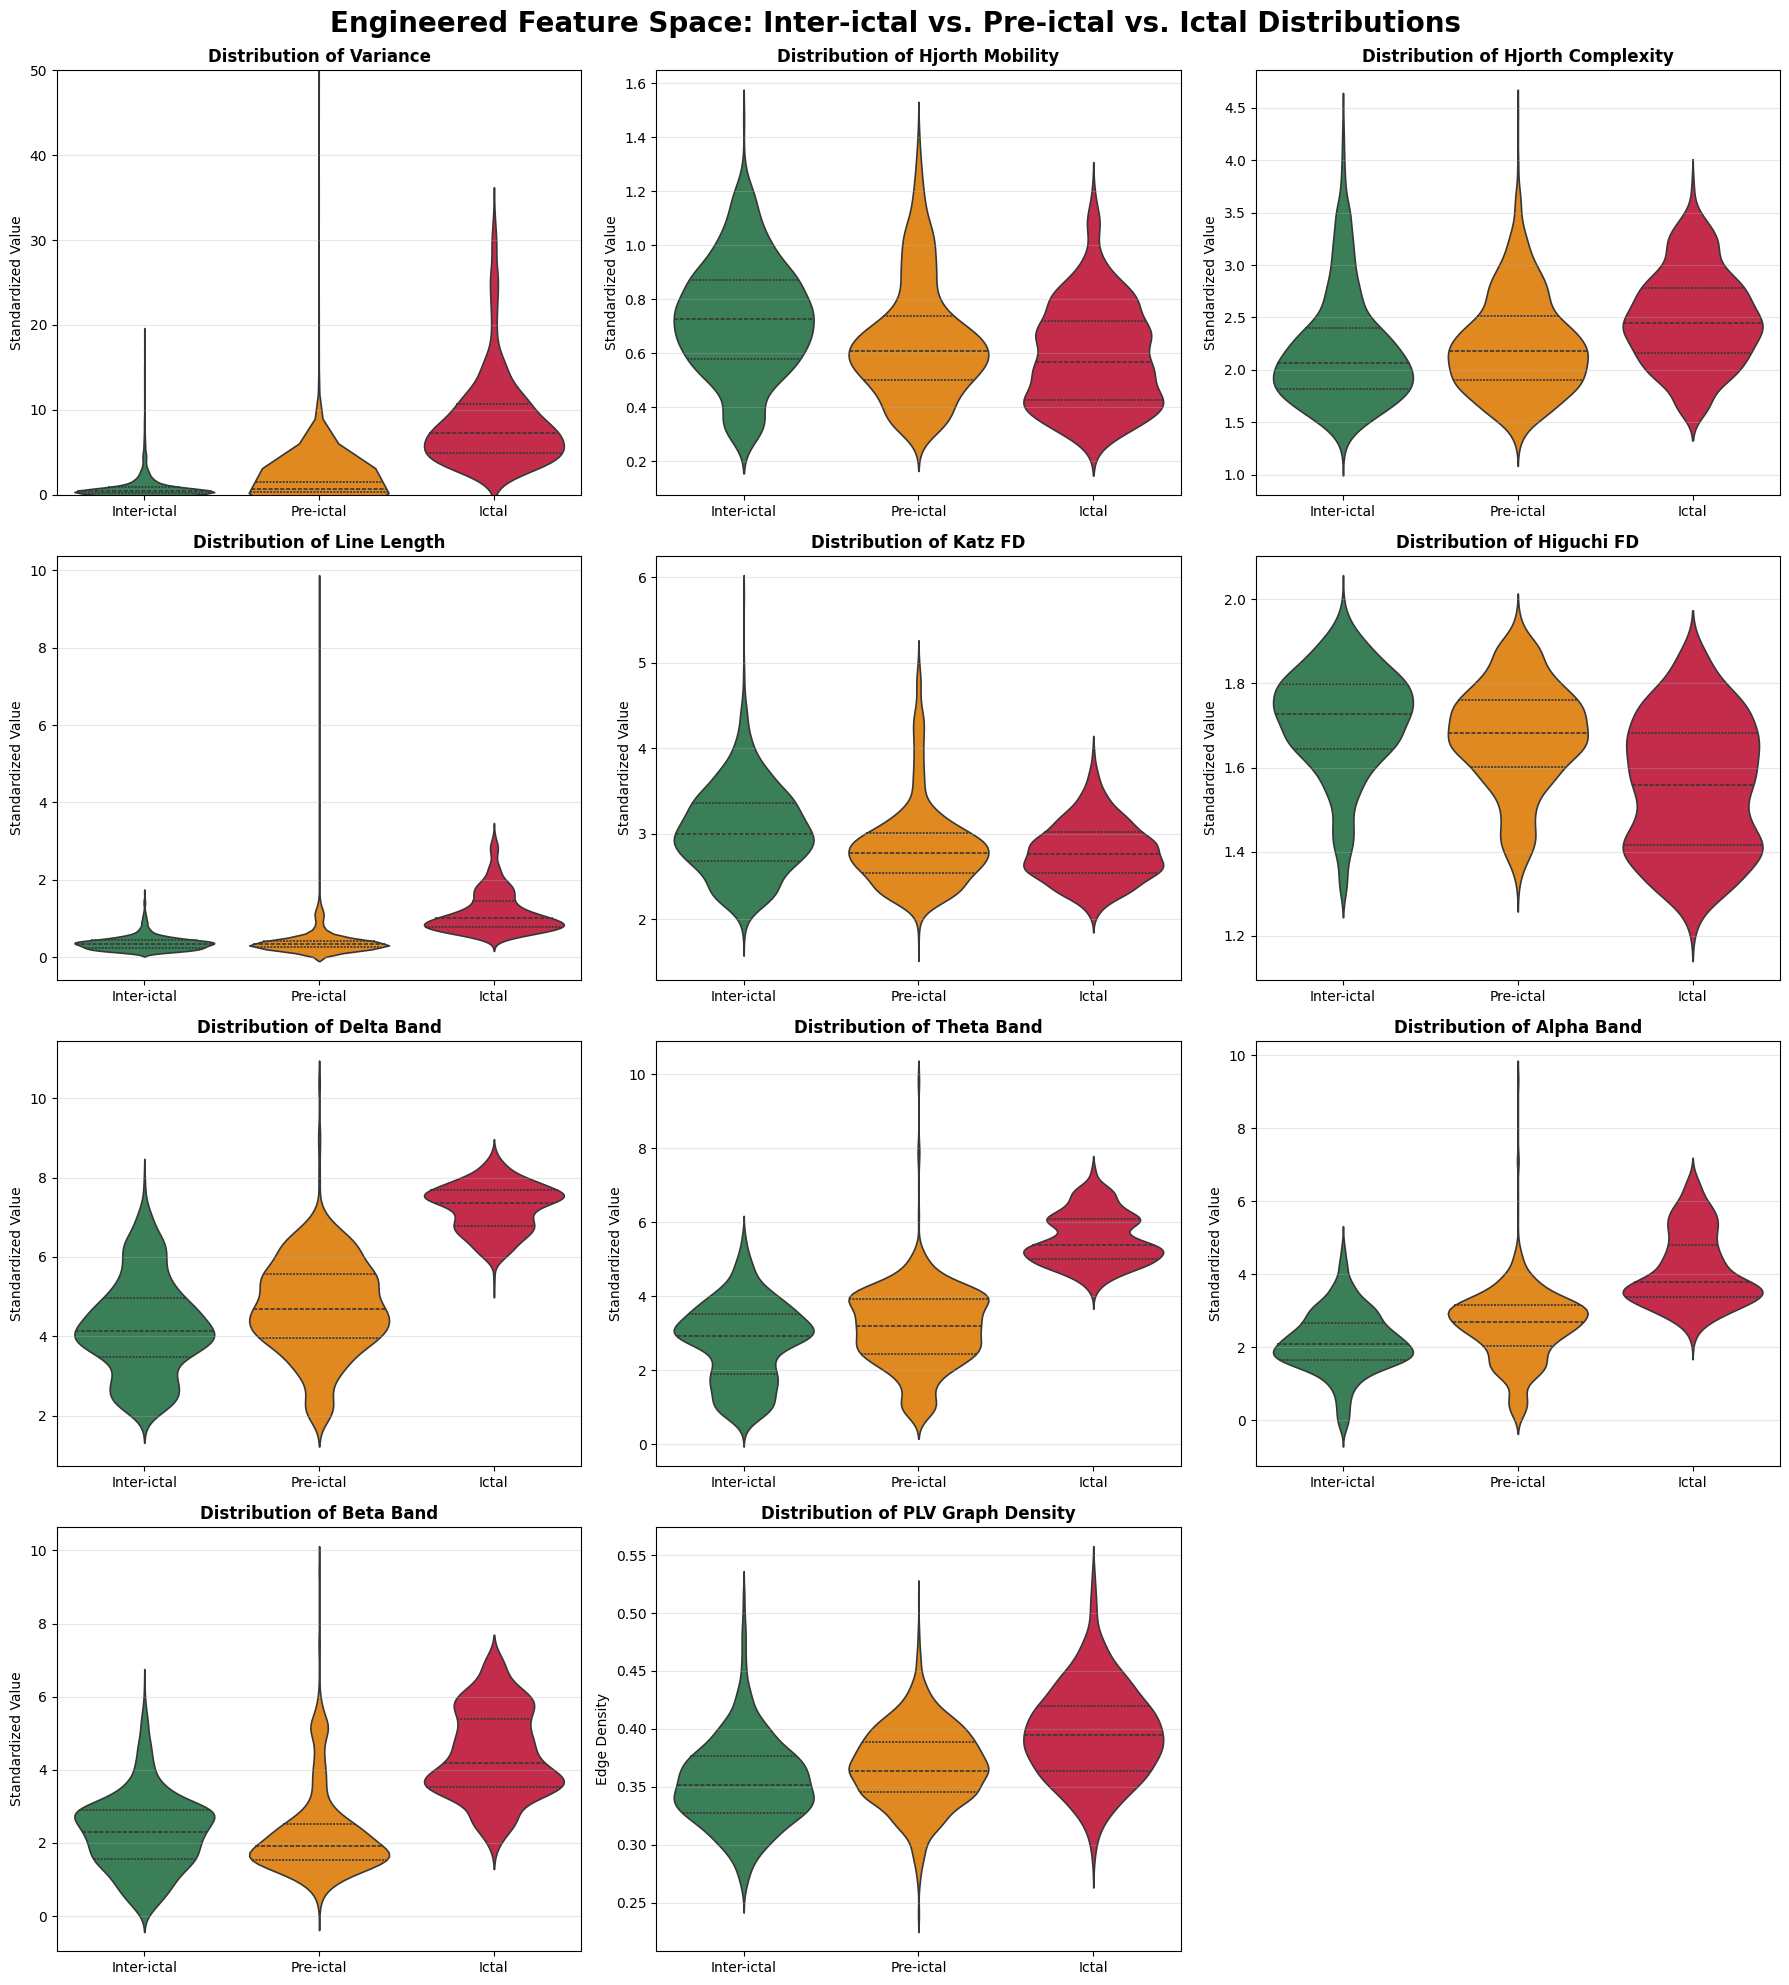

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch_geometric.data.separate import separate
from torch_geometric.data import Data

def plot_all_feature_distributions(pt_dir):
    """Loads .pt files and plots violin distributions for all features and PLV."""

    # Feature order based on dataloader_utils.py
    feature_names = [
        'Variance', 'Hjorth Mobility', 'Hjorth Complexity', 'Line Length',
        'Katz FD', 'Higuchi FD', 'Delta Band', 'Theta Band', 'Alpha Band', 'Beta Band'
    ]

    # Class mapping
    class_map = {0: 'Pre-ictal', 1: 'Ictal', 2: 'Inter-ictal'}

    all_features = []
    all_labels = []
    all_plv_densities = []

    # Load a subset of files to avoid RAM overload (e.g., first 3 patients)
    pt_files = [f for f in os.listdir(pt_dir) if f.endswith('.pt')][:3]

    print("Extracting features from tensors...")
    for file in pt_files:
        filepath = os.path.join(pt_dir, file)
        data_collated, slices = torch.load(filepath, weights_only=False)

        # Separate the collated data back into individual graphs
        num_graphs = len(data_collated.y)
        for i in range(num_graphs):
            graph = separate(Data, data_collated, i, slices, decrement=False)

            # Average the features across all 18 nodes for a global graph-level view
            avg_features = graph.x.numpy().mean(axis=0)
            label = int(graph.y.item())

            # Proxy for PLV Connectivity: Graph Density
            num_edges = graph.edge_index.shape[1]
            max_edges = 18 * 18
            density = num_edges / max_edges

            all_features.append(avg_features)
            all_labels.append(class_map[label])
            all_plv_densities.append(density)

    # Create DataFrame
    df_features = pd.DataFrame(all_features, columns=feature_names)
    df_features['Class'] = all_labels
    df_features['PLV Graph Density'] = all_plv_densities

    # --- Plotting ---
    fig, axes = plt.subplots(4, 3, figsize=(18, 20))
    axes = axes.flatten()

    plot_vars = feature_names + ['PLV Graph Density']

    # Custom color palette matching our previous graphs
    palette = {'Inter-ictal': 'seagreen', 'Pre-ictal': 'darkorange', 'Ictal': 'crimson'}

    for i, var in enumerate(plot_vars):
        sns.violinplot(
            data=df_features,
            x='Class',
            y=var,
            ax=axes[i],
            hue='Class',          # Assign x variable to hue
            palette=palette,
            order=['Inter-ictal', 'Pre-ictal', 'Ictal'],
            inner="quartile",
            linewidth=1.2,
            legend=False          # Disable legend to avoid duplication
        )
        axes[i].set_title(f"Distribution of {var}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Standardized Value" if var != 'PLV Graph Density' else "Edge Density")
        axes[i].grid(True, alpha=0.3, axis='y')

        # FIX: Clamp the Y-axis for Variance specifically to 0-50
        if var == 'Variance':
            axes[i].set_ylim(0, 50)

    # Hide the 12th empty subplot
    axes[11].axis('off')

    plt.suptitle("Engineered Feature Space: Inter-ictal vs. Pre-ictal vs. Ictal Distributions",
                 fontsize=20, fontweight='bold', y=0.99)
    plt.tight_layout()
    plt.savefig('Comprehensive_Feature_Distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    pt_directory = '/cache/train'
    plot_all_feature_distributions(pt_directory)

## **4.5.4 Functional Connectivity: Defining Graph Edges**


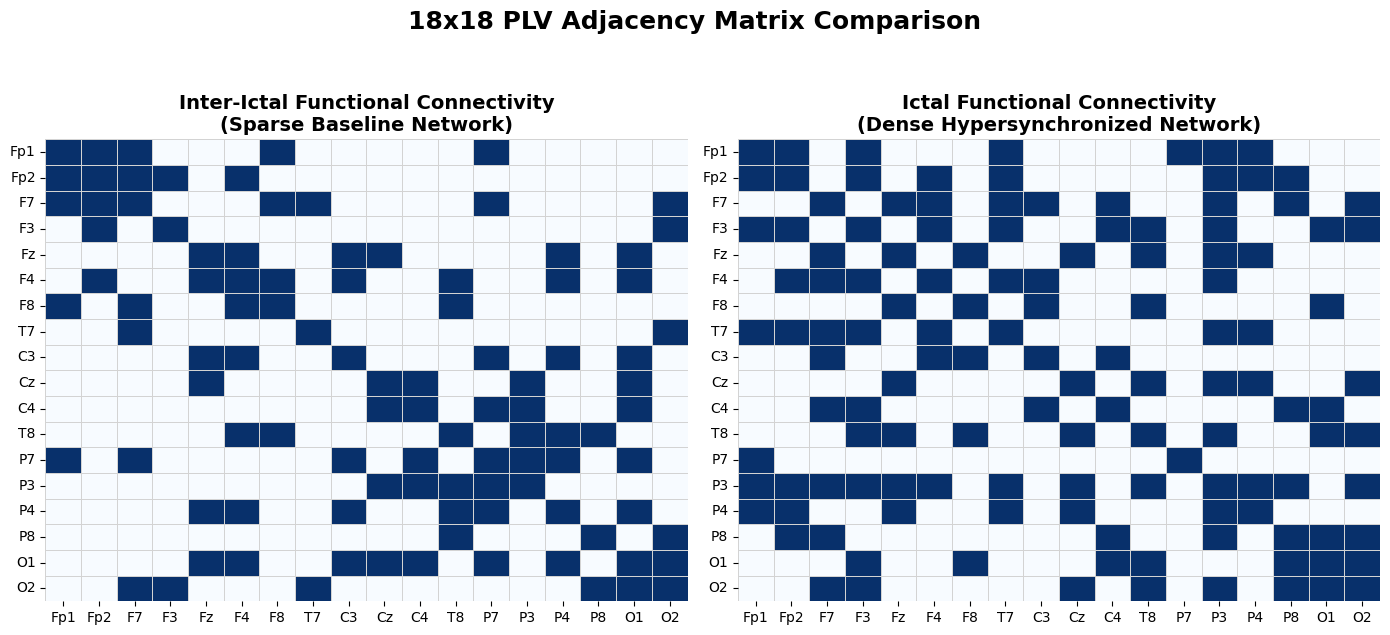

In [ ]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torch_geometric.data.separate import separate
from torch_geometric.data import Data
from torch_geometric.utils import to_dense_adj

def plot_plv_adjacency_heatmaps(pt_dir):
    """Loads a .pt file, reconstructs dense adjacency matrices, and plots Interictal vs Ictal."""

    # 18 Channels used in standard montage
    channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
                'T7', 'C3', 'Cz', 'C4', 'T8',
                'P7', 'P3', 'P4', 'P8', 'O1', 'O2']

    # Grab the first available .pt file
    pt_files = [f for f in os.listdir(pt_dir) if f.endswith('.pt')]
    filepath = os.path.join(pt_dir, pt_files[0])

    data_collated, slices = torch.load(filepath, weights_only=False)
    num_graphs = len(data_collated.y)

    interictal_adj = None
    ictal_adj = None

    # Search for one clean representative sample of each class
    for i in range(num_graphs):
        graph = separate(Data, data_collated, i, slices, decrement=False)
        label = int(graph.y.item())

        # 2 = Inter-ictal, 1 = Ictal
        if label == 2 and interictal_adj is None:
            # Convert edge_index [2, E] back to a dense 18x18 matrix
            interictal_adj = to_dense_adj(graph.edge_index, max_num_nodes=18)[0].numpy()
        elif label == 1 and ictal_adj is None:
            ictal_adj = to_dense_adj(graph.edge_index, max_num_nodes=18)[0].numpy()

        if interictal_adj is not None and ictal_adj is not None:
            break

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # using a binary color map because dataloader applies a threshold to create binary edges
    cmap = sns.color_palette("Blues", as_cmap=True)

    # Plot Interictal
    sns.heatmap(interictal_adj, ax=axes[0], cmap=cmap, cbar=False,
                xticklabels=channels, yticklabels=channels, linewidths=0.5, linecolor='lightgray')
    axes[0].set_title("Inter-Ictal Functional Connectivity\n(Sparse Baseline Network)", fontsize=14, fontweight='bold')

    # Plot Ictal
    sns.heatmap(ictal_adj, ax=axes[1], cmap=cmap, cbar=False,
                xticklabels=channels, yticklabels=channels, linewidths=0.5, linecolor='lightgray')
    axes[1].set_title("Ictal Functional Connectivity\n(Dense Hypersynchronized Network)", fontsize=14, fontweight='bold')

    plt.suptitle("18x18 PLV Adjacency Matrix Comparison", fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('PLV_Adjacency_Matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    pt_directory = '/cache/train'
    plot_plv_adjacency_heatmaps(pt_directory)

## **4.5.5 Data Standardization and Outlier Robustness**


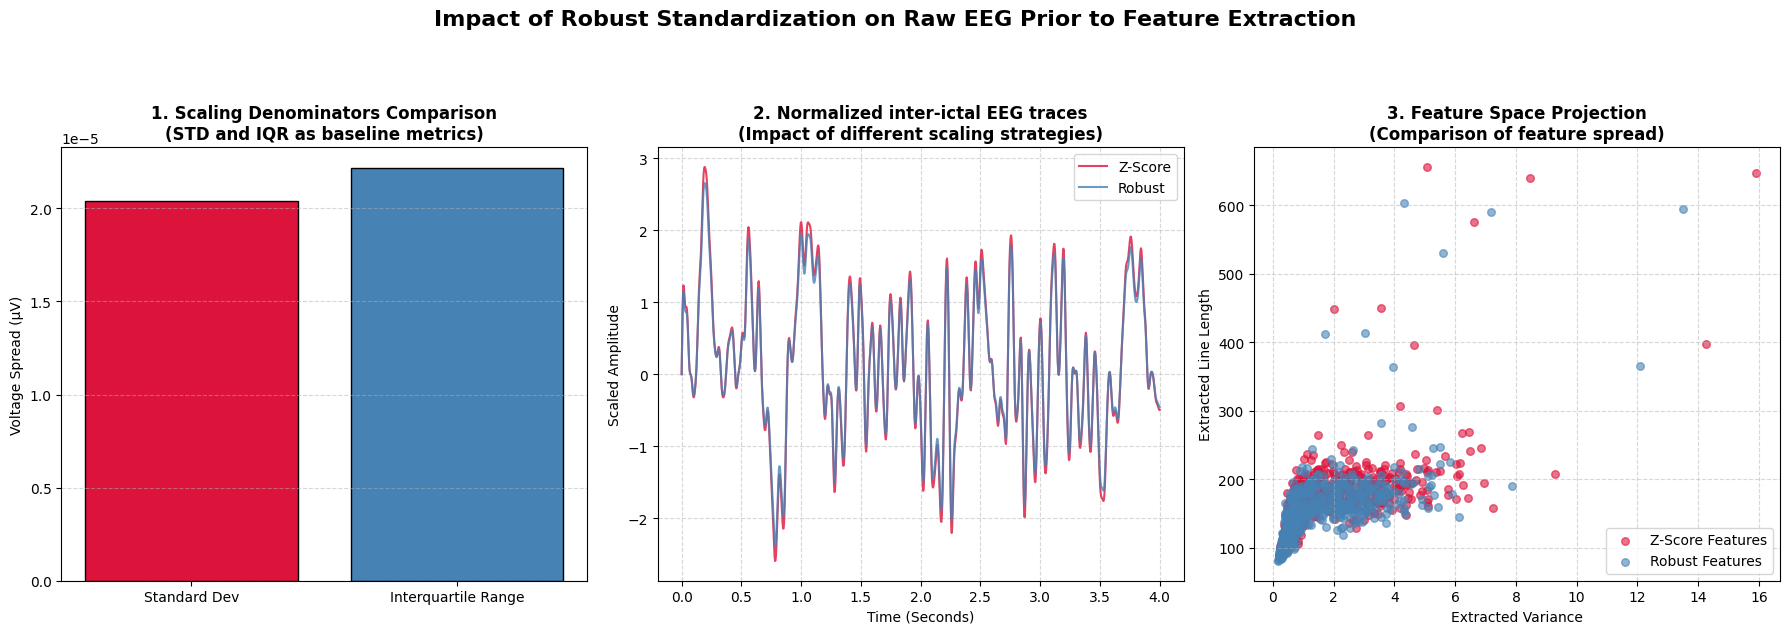

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import iqr

def plot_comprehensive_standardization_analysis(npy_file_path, sampling_rate=256, window_seconds=6):
    # generate visual comparison between robust scaling and standard z-score for EEG
    
    # load data and ensure (channels, time) format
    data = np.load(npy_file_path)
    if data.shape[0] > data.shape[1]:
        data = data.T 

    # use first channel for time-domain demo
    channel_idx = 0
    raw_signal = data[channel_idx, :]

    # extract first 3 minutes to simulate a clean baseline
    baseline_signal = raw_signal[:sampling_rate * 180]

    # compute scaling metrics on the baseline
    mean_val = np.mean(baseline_signal)
    std_val = np.std(baseline_signal)
    median_val = np.median(baseline_signal)
    iqr_val = iqr(baseline_signal)

    # apply standard and robust scaling
    z_scaled_signal = (raw_signal - mean_val) / std_val
    robust_scaled_signal = (raw_signal - median_val) / iqr_val

    # chunk data into windows
    window_size = sampling_rate * window_seconds
    num_windows = len(raw_signal) // window_size

    z_windows = z_scaled_signal[:num_windows * window_size].reshape(num_windows, window_size)
    rob_windows = robust_scaled_signal[:num_windows * window_size].reshape(num_windows, window_size)

    # extract variance and line length features
    z_variance = np.var(z_windows, axis=1)
    rob_variance = np.var(rob_windows, axis=1)

    z_line_length = np.sum(np.abs(np.diff(z_windows, axis=1)), axis=1)
    rob_line_length = np.sum(np.abs(np.diff(rob_windows, axis=1)), axis=1)

    # plot layout
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # plot 1: compare scaling denominators
    axes[0].bar(['Standard Dev', 'Interquartile Range'], [std_val, iqr_val], color=['crimson', 'steelblue'], edgecolor='black')
    axes[0].set_title("1. Scaling Denominators Comparison\n(STD and IQR as baseline metrics)", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Voltage Spread (µV)")
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # plot 2: time domain traces (4-second window)
    time_axis = np.linspace(0, 4, sampling_rate * 4)
    axes[1].plot(time_axis, z_scaled_signal[:sampling_rate * 4], color='crimson', label='Z-Score', alpha=0.8)
    axes[1].plot(time_axis, robust_scaled_signal[:sampling_rate * 4], color='steelblue', label='Robust', alpha=0.8)
    axes[1].set_title("2. Normalized inter-ictal EEG traces\n(Impact of different scaling strategies)", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Time (Seconds)")
    axes[1].set_ylabel("Scaled Amplitude")
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)

    # plot 3: feature space scatter
    axes[2].scatter(z_variance, z_line_length, color='crimson', alpha=0.6, label='Z-Score Features', s=30)
    axes[2].scatter(rob_variance, rob_line_length, color='steelblue', alpha=0.6, label='Robust Features', s=30)
    axes[2].set_title("3. Feature Space Projection\n(Comparison of feature spread)", fontsize=12, fontweight='bold')
    axes[2].set_xlabel("Extracted Variance")
    axes[2].set_ylabel("Extracted Line Length")
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.5)

    # finalize and save
    plt.suptitle("Impact of Robust Standardization on Raw EEG Prior to Feature Extraction", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('Comprehensive_Standardization_Analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    sample_npy_path = '/numpy_output/chb01/seizures_chb01_03.npy'
    plot_comprehensive_standardization_analysis(sample_npy_path)